In [1]:
import pandas as pd
import numpy as np
import torch as tc
import torch.nn as nn
from scipy.integrate import solve_ivp 

import matplotlib.pyplot as plt
from matplotlib import cm, rc

import time
import pickle

In [ ]:
## PROBLEM 2.1(a)

In [2]:
# time span
t_total = 90
t_scale = 1
t_end = 90
t_span = (0/t_scale, t_end/t_scale)           # from 0 to 1
t_eval = np.linspace(0, t_end, t_total)/t_scale

alpha = 0.6; beta = 0.025; delta = 0.0125; gamma = 0.5 

# define first-order system
def lynxhare(t, z):
    x, y = z
    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y
    return [dxdt, dydt]

# solve IVP
x0 = 30; y0 = 4 
sol = solve_ivp(lynxhare, t_span, [x0, y0], t_eval=t_eval)


x = tc.from_numpy(sol.y[0])
y = tc.from_numpy(sol.y[1])


In [23]:
x.shape

torch.Size([90])

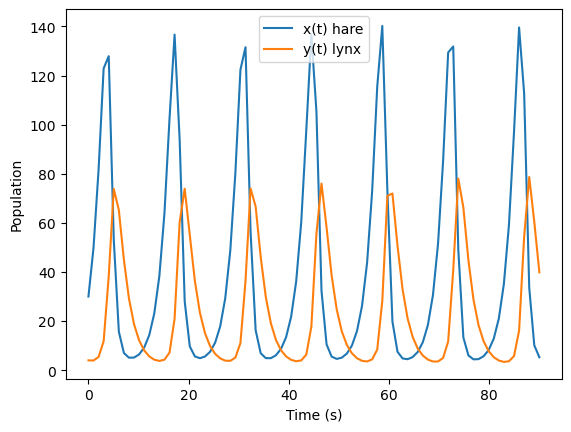

In [25]:
plt.plot(t_eval, x, label="x(t) hare")
plt.plot(t_eval, y, label="y(t) lynx")

plt.xlabel("Time (s)")
plt.ylabel("Population")
plt.legend()
plt.show()

In [ ]:
## PROBLEM 2.1(b)

In [3]:
def der(t, x):
    dxdt = (x[2:] - x[:-2]) / (t[2:] - t[:-2])
    return dxdt

In [26]:
yder = der(t_eval, y)
xder = der(t_eval, x)

C:\Users\fabbasi\AppData\Local\Temp\ipykernel_28776\3564429836.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dxdt = (x[2:] - x[:-2]) / (t[2:] - t[:-2])


In [ ]:
## PROBLEM 2.1(c)

In [44]:
ders = []
for i in range(len(xder)): 
    ders.append([xder[i]])
    ders.append([yder[i]])

ders = np.array(ders)

In [48]:
A = []
for i in range(1, t_end-1): 
    A.append([x[i], -x[i]*y[i], 0, 0])
    A.append([0, 0, -y[i], x[i]*y[i]])

A = np.array(A)

In [ ]:
omega = np.linalg.inv(np.matrix_transpose(A) @ A) @ np.matrix_transpose(A) @ ders
print(f"Parameters are computed to be alpha = {omega[0][0]:.3f} (0.6), beta = {omega[1][0]:.3f} (0.025), gamma = {omega[2][0]:.3f} (0.5), delta = {omega[3][0]:.3f} (0.0125)") 

Parameters are computed to be alpha = 0.478 (0.6), beta = 0.020 (0.025), gamma = 0.395 (0.5), delta = 0.010 (0.0125)


In [61]:
alpha = omega[0][0]
beta = omega[1][0]
gamma = omega[2][0]
delta = omega[3][0]

# solve IVP
sol_pred = solve_ivp(lynxhare, t_span, [x0, y0], t_eval=t_eval)


x_pred = tc.from_numpy(sol_pred.y[0])
y_pred = tc.from_numpy(sol_pred.y[1])

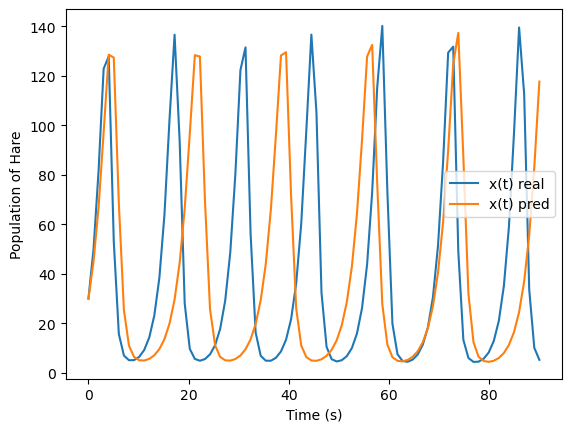

In [63]:
plt.plot(t_eval, x, label="x(t) real")
plt.plot(t_eval, x_pred, label="x(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Hare")
plt.legend()
plt.show()

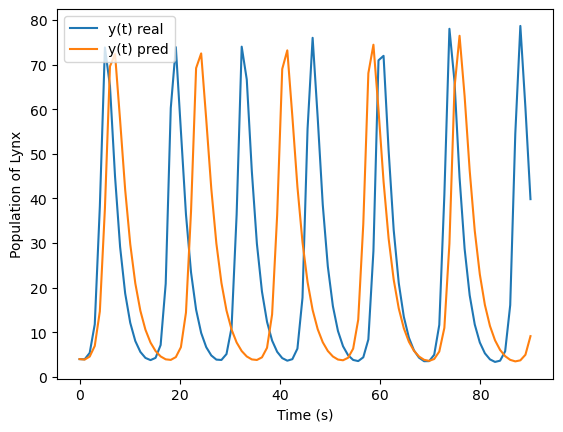

In [64]:
plt.plot(t_eval, y, label="y(t) real")
plt.plot(t_eval, y_pred, label="y(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Lynx")
plt.legend()
plt.show()

In [ ]:
## PROBLEM 2.1(d)
# use 30 points / year 

In [74]:
t_total = 90*30
t_eval = np.linspace(0, t_end, t_total)/t_scale

alpha = 0.6; beta = 0.025; delta = 0.0125; gamma = 0.5 

x0 = 30; y0 = 4 
sol = solve_ivp(lynxhare, t_span, [x0, y0], t_eval=t_eval)


x = tc.from_numpy(sol.y[0])
y = tc.from_numpy(sol.y[1])

yder = der(t_eval, y)
xder = der(t_eval, x)

ders = []
for i in range(len(xder)): 
    ders.append([xder[i]])
    ders.append([yder[i]])

ders = np.array(ders)

A = []
for i in range(1, len(x)-1): 
    A.append([x[i], -x[i]*y[i], 0, 0])
    A.append([0, 0, -y[i], x[i]*y[i]])

A = np.array(A)

omega = np.linalg.inv(np.matrix_transpose(A) @ A) @ np.matrix_transpose(A) @ ders
print(f"Parameters are computed to be alpha = {omega[0][0]:.3f} (0.6), beta = {omega[1][0]:.3f} (0.025), gamma = {omega[2][0]:.3f} (0.5), delta = {omega[3][0]:.4f} (0.0125)") 

Parameters are computed to be alpha = 0.599 (0.6), beta = 0.025 (0.025), gamma = 0.498 (0.5), delta = 0.0125 (0.0125)


C:\Users\fabbasi\AppData\Local\Temp\ipykernel_28776\3564429836.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dxdt = (x[2:] - x[:-2]) / (t[2:] - t[:-2])


In [75]:
alpha = omega[0][0]
beta = omega[1][0]
gamma = omega[2][0]
delta = omega[3][0]

# solve IVP
sol_pred = solve_ivp(lynxhare, t_span, [x0, y0], t_eval=t_eval)


x_pred = tc.from_numpy(sol_pred.y[0])
y_pred = tc.from_numpy(sol_pred.y[1])

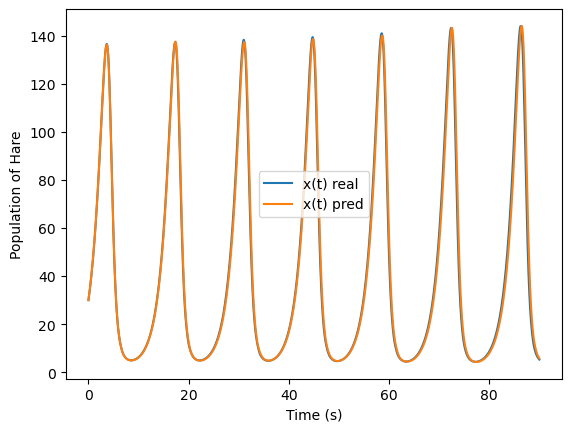

In [76]:
plt.plot(t_eval, x, label="x(t) real")
plt.plot(t_eval, x_pred, label="x(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Hare")
plt.legend()
plt.show()

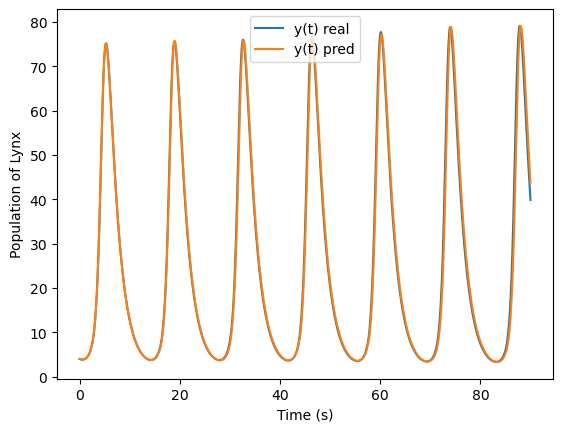

In [77]:
plt.plot(t_eval, y, label="y(t) real")
plt.plot(t_eval, y_pred, label="y(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Lynx")
plt.legend()
plt.show()

In [ ]:
## PROBLEM 2.2 

In [119]:
file = pd.read_csv("lotvol.csv")

time = file["year"].to_numpy()
hare = file["hare"].to_numpy()
lynx = file["lynx"].to_numpy()

sort_idx = np.argsort(time)
time = time[sort_idx]
time = time - time[0]
hare = hare[sort_idx]/1000
lynx = lynx[sort_idx]/1000

In [120]:
yder = der(time, lynx)
xder = der(time, hare)

ders = []
for i in range(len(xder)): 
    ders.append([xder[i]])
    ders.append([yder[i]])

ders = np.array(ders)

A = []
for i in range(1, len(hare)-1): 
    A.append([hare[i], -hare[i]*lynx[i], 0, 0])
    A.append([0, 0, -lynx[i], hare[i]*lynx[i]])

A = np.array(A)

omega = np.linalg.inv(np.matrix_transpose(A) @ A) @ np.matrix_transpose(A) @ ders
print(f"Parameters are computed to be alpha = {omega[0][0]:.3f}, beta = {omega[1][0]:.3f}, gamma = {omega[2][0]:.3f}, delta = {omega[3][0]:.4f}") 

Parameters are computed to be alpha = 0.471, beta = 0.022, gamma = 0.708, delta = 0.0199


In [121]:
alpha = omega[0][0]
beta = omega[1][0]
gamma = omega[2][0]
delta = omega[3][0]

# solve IVP
sol_pred = solve_ivp(lynxhare, (time[0], time[-1]), [x0, y0], t_eval=time)


x_pred = tc.from_numpy(sol_pred.y[0])
y_pred = tc.from_numpy(sol_pred.y[1])

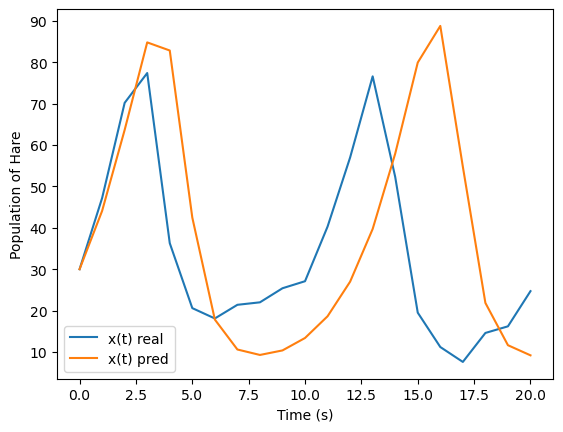

In [122]:
plt.plot(time, hare, label="x(t) real")
plt.plot(time, x_pred, label="x(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Hare")
plt.legend()
plt.show()

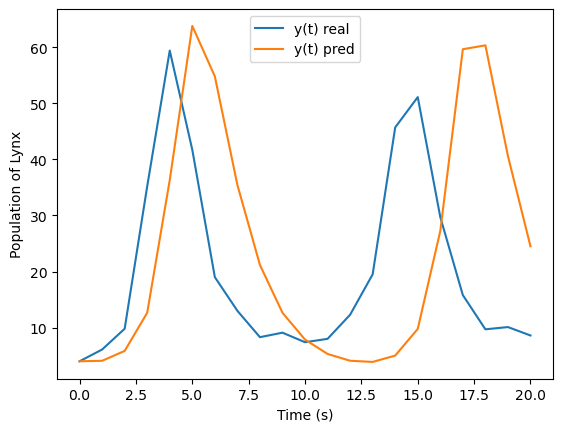

In [124]:
plt.plot(time, lynx, label="y(t) real")
plt.plot(time, y_pred, label="y(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Lynx")
plt.legend()
plt.show()

In [ ]:
## FOR LEIGH1968

In [125]:
file = pd.read_csv("Leigh1968_harelynx.csv")

time = file["year"].to_numpy()
hare = file["hare"].to_numpy()
lynx = file["lynx"].to_numpy()

sort_idx = np.argsort(time)
time = time[sort_idx]
time = time - time[0]
hare = hare[sort_idx]/1000
lynx = lynx[sort_idx]/1000

yder = der(time, lynx)
xder = der(time, hare)

ders = []
for i in range(len(xder)): 
    ders.append([xder[i]])
    ders.append([yder[i]])

ders = np.array(ders)

A = []
for i in range(1, len(hare)-1): 
    A.append([hare[i], -hare[i]*lynx[i], 0, 0])
    A.append([0, 0, -lynx[i], hare[i]*lynx[i]])

A = np.array(A)

omega = np.linalg.inv(np.matrix_transpose(A) @ A) @ np.matrix_transpose(A) @ ders
print(f"Parameters are computed to be alpha = {omega[0][0]:.3f}, beta = {omega[1][0]:.3f}, gamma = {omega[2][0]:.3f}, delta = {omega[3][0]:.4f}") 

alpha = omega[0][0]
beta = omega[1][0]
gamma = omega[2][0]
delta = omega[3][0]

# solve IVP
sol_pred = solve_ivp(lynxhare, (time[0], time[-1]), [x0, y0], t_eval=time)


x_pred = tc.from_numpy(sol_pred.y[0])
y_pred = tc.from_numpy(sol_pred.y[1])

Parameters are computed to be alpha = -0.006, beta = -0.000, gamma = -0.060, delta = -0.0007


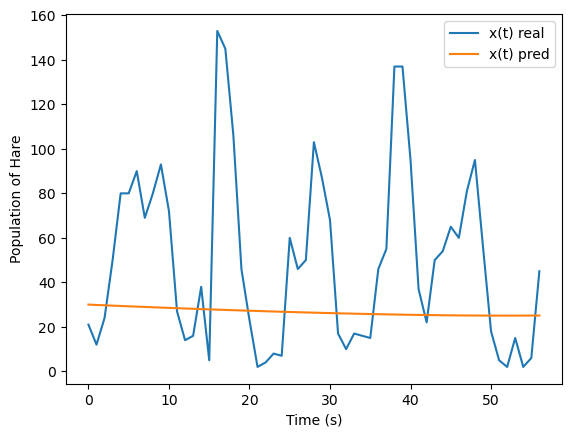

In [126]:
plt.plot(time, hare, label="x(t) real")
plt.plot(time, x_pred, label="x(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Hare")
plt.legend()
plt.show()

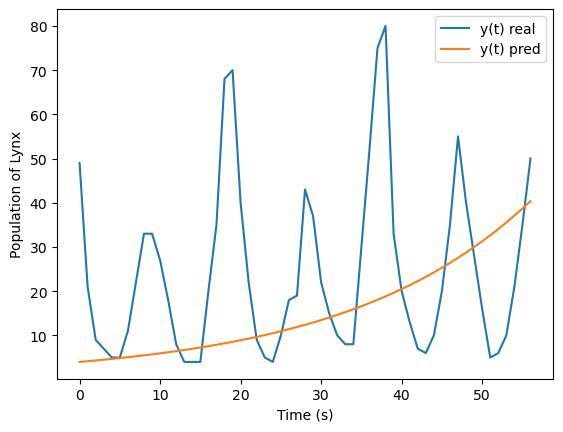

In [127]:
plt.plot(time, lynx, label="y(t) real")
plt.plot(time, y_pred, label="y(t) pred")

plt.xlabel("Time (s)")
plt.ylabel("Population of Lynx")
plt.legend()
plt.show()

In [ ]:
## PROBLEM 2.3 (a)

In [ ]:
## synthetic data 

In [3]:
class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()]) #* unpacks list into argument 
        self.fch = nn.Sequential(*[##hidden layer
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])##inner Sequential defines one block: linear+activation ##outer Sequential chain the blocks together
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)##last layer
        
    def forward(self, x): ###The forward() method defines the computation of the network., we don't call forward function, the network internally calls it
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [4]:
def plot_result(x, y, x_data, y_data, yh, xp=None, step=None):
    "Pretty plot training results (time-based lynx–hare)"
    
    # convert PyTorch tensors to NumPy arrays if needed
    if isinstance(x, tc.Tensor):
        x = x.detach().cpu().numpy()
    if isinstance(y, tc.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(x_data, tc.Tensor):
        x_data = x_data.detach().cpu().numpy()
    if isinstance(y_data, tc.Tensor):
        y_data = y_data.detach().cpu().numpy()
    if isinstance(yh, tc.Tensor):
        yh = yh.detach().cpu().numpy()
    if xp is not None and isinstance(xp, tc.Tensor):
        xp = xp.detach().cpu().numpy()
    
    plt.figure(figsize=(8,4))
    plt.plot(x, y[:,0], color="grey", linewidth=2, alpha=0.8, label="Hare exact")
    plt.plot(x, y[:,1], color="grey", linewidth=2, alpha=0.8, label="Lynx exact")
    plt.plot(x, yh[:,0], color="tab:blue", linewidth=3, alpha=0.8, label="Hare NN pred")
    plt.plot(x, yh[:,1], color="tab:green", linewidth=3, alpha=0.8, label="Lynx NN pred")
    
    plt.scatter(x_data, y_data[:,0], s=60, color="tab:orange", alpha=0.4, label='Hare training')
    plt.scatter(x_data, y_data[:,1], s=60, color="tab:red", alpha=0.4, label='Lynx training')
    
    if xp is not None:
        plt.scatter(xp, np.zeros_like(xp), s=60, color="tab:purple", alpha=0.4, label='Physics loss locations')
    
    plt.legend(loc="best", frameon=False, fontsize="large")
    
    if step is not None:
        plt.text(0.95, 0.9, f"Training step: {step}", transform=plt.gca().transAxes, fontsize="large")
    
    plt.xlabel("Time (scaled)")
    plt.ylabel("Population")
    plt.show()

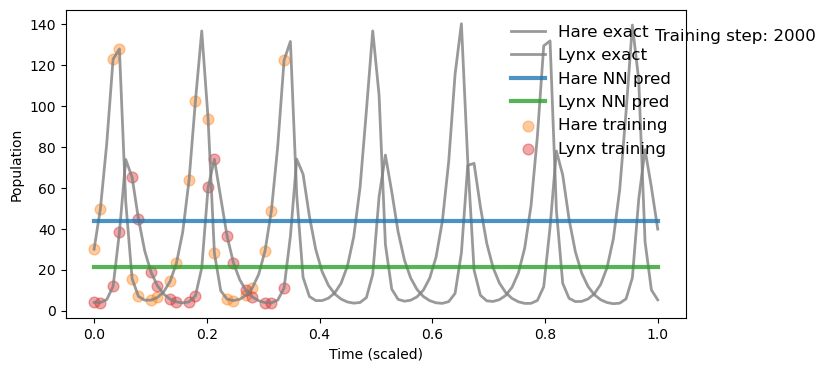

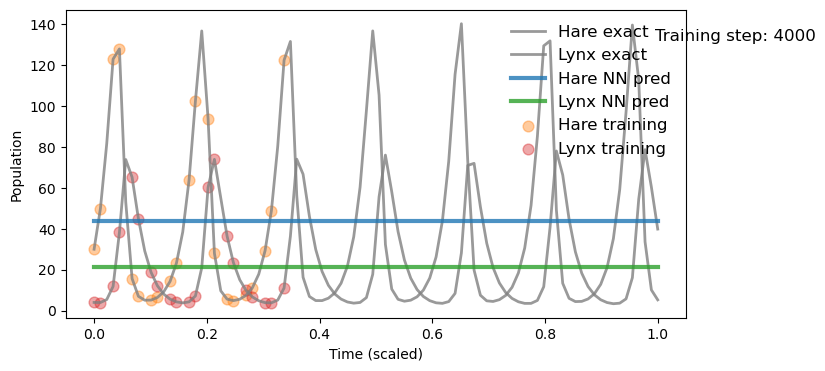

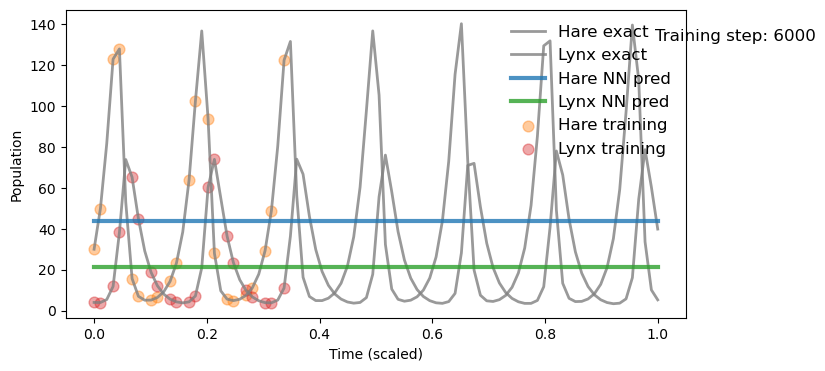

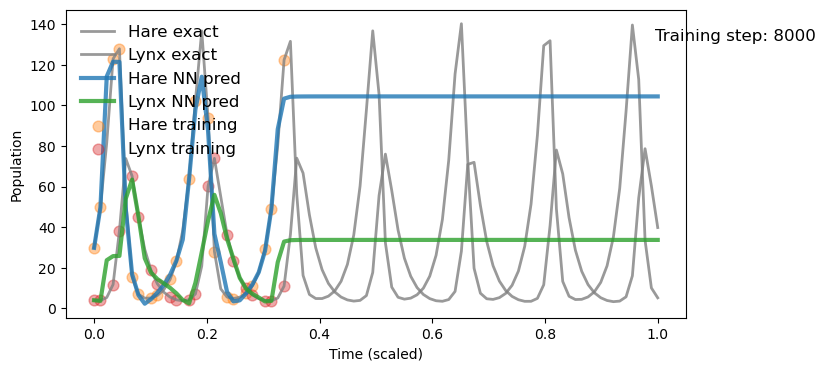

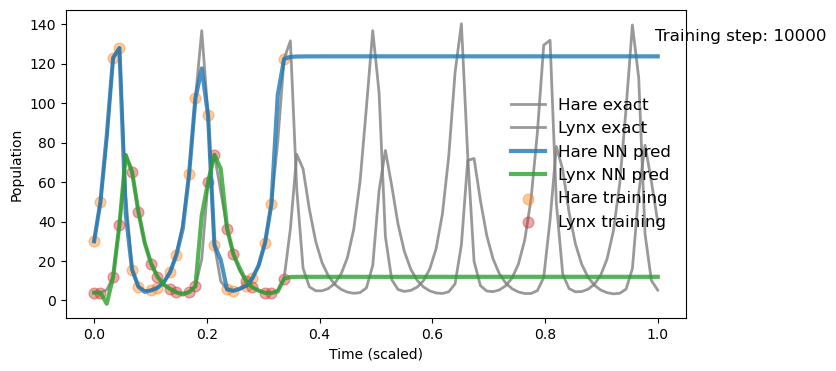

In [11]:
t_total = 90
t_eval = np.linspace(0, t_end, t_total)/t_scale
t_eval = tc.from_numpy(t_eval).float().unsqueeze(1)
x = tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y = tc.from_numpy(sol.y[1]).unsqueeze(1).float()

t_eval /= 90 
###########################################################
sel_end = (x.shape[0])//3 
obs = 2*sel_end//3 + 1 
sel = np.linspace(0, sel_end, obs)
sel = np.int32(sel)

t_data = t_eval[sel]
x_data =  x[sel]
y_data =  y[sel]
all_data = np.hstack([x, y]) 
sel_data = np.hstack([x_data, y_data]) 

all_data = tc.from_numpy(all_data).float()  
sel_data = tc.from_numpy(sel_data).float()  

# train standard neural network to fit training data
tc.manual_seed(123)
model = FCN(1, 2, 64, 4) # one input two outputs, 64 neurons, 4 layers
optimizer = tc.optim.Adam(model.parameters(),lr=1e-3)

for i in range(10000):
    optimizer.zero_grad()
    pred = model(t_data)
    loss = tc.mean((pred - sel_data)**2)
    loss.backward()
    optimizer.step()    
    
    # plot the result as training progresses
    if (i+1) % 2000 == 0: 
        pred = model(t_eval).detach()
        plot_result(t_eval, all_data, t_data, sel_data, pred, step=i+1)        
        plt.show()

In [ ]:
## as expected, it does not work well after the training points end 

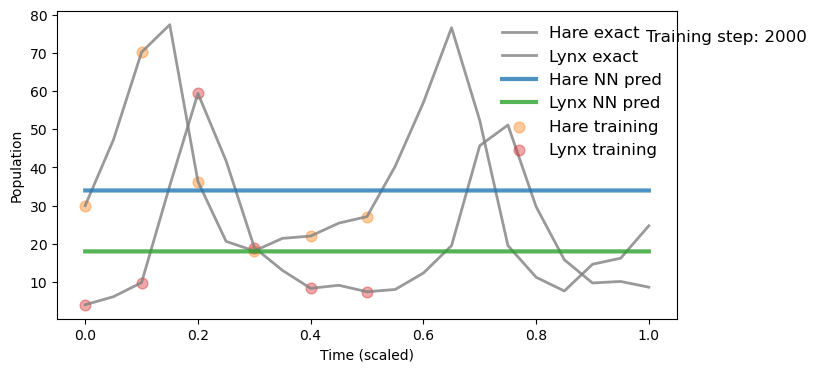

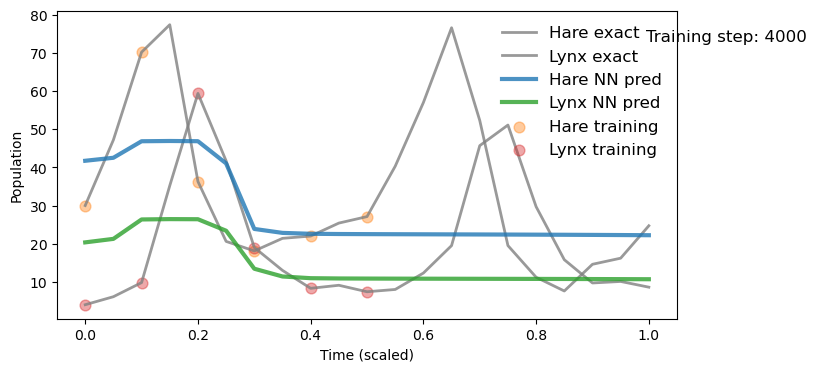

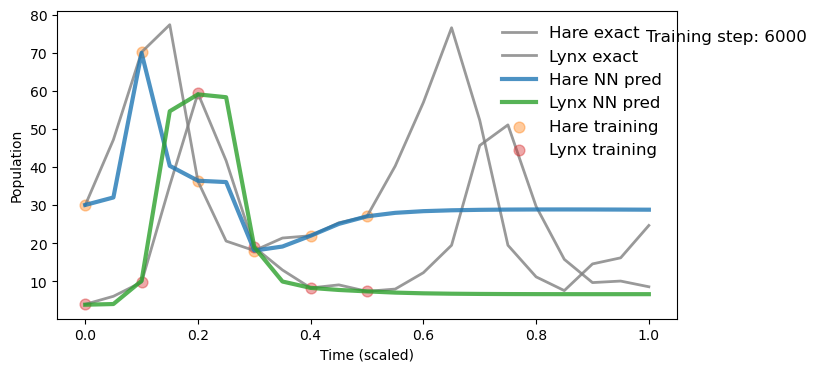

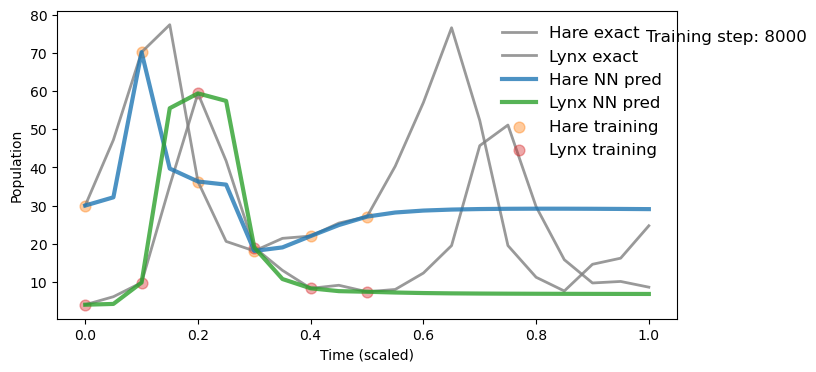

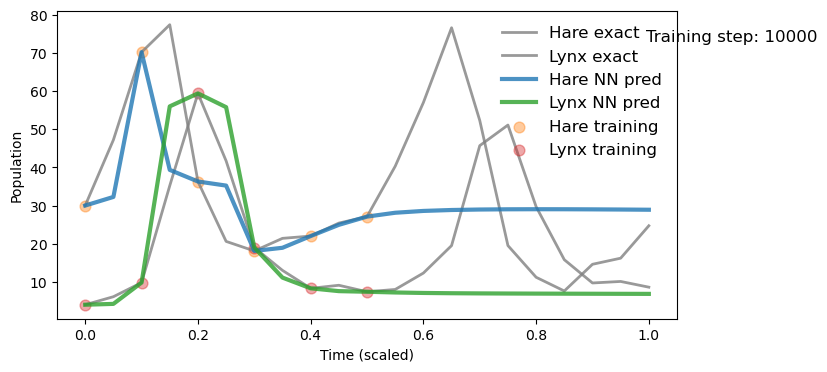

In [10]:
## lotvol 

file = pd.read_csv("lotvol.csv")

time = file["year"].to_numpy()
hare = file["hare"].to_numpy()
lynx = file["lynx"].to_numpy()

sort_idx = np.argsort(time)
time = time[sort_idx]
time = time - time[0]
time = time / time[-1]
hare = hare[sort_idx]/1000
lynx = lynx[sort_idx]/1000


t_eval = tc.from_numpy(time).float().unsqueeze(1)
x = tc.from_numpy(hare).unsqueeze(1).float()
y = tc.from_numpy(lynx).unsqueeze(1).float()

###########################################################
sel_end = (x.shape[0])//2
obs = sel_end//2 + 1 
sel = np.linspace(0, sel_end, obs)
sel = np.int32(sel)

t_data = t_eval[sel]
x_data =  x[sel]
y_data =  y[sel]
all_data = np.hstack([x, y]) 
sel_data = np.hstack([x_data, y_data]) 

all_data = tc.from_numpy(all_data).float()  
sel_data = tc.from_numpy(sel_data).float()  

# train standard neural network to fit training data
tc.manual_seed(123)
model = FCN(1, 2, 64, 4) # one input two outputs, 64 neurons, 4 layers
optimizer = tc.optim.Adam(model.parameters(),lr=1e-3)

for i in range(10000):
    optimizer.zero_grad()
    pred = model(t_data)
    loss = tc.mean((pred - sel_data)**2)
    loss.backward()
    optimizer.step()    
    
    # plot the result as training progresses
    if (i+1) % 2000 == 0: 
        pred = model(t_eval).detach()
        plot_result(t_eval, all_data, t_data, sel_data, pred, step=i+1)        
        plt.show()

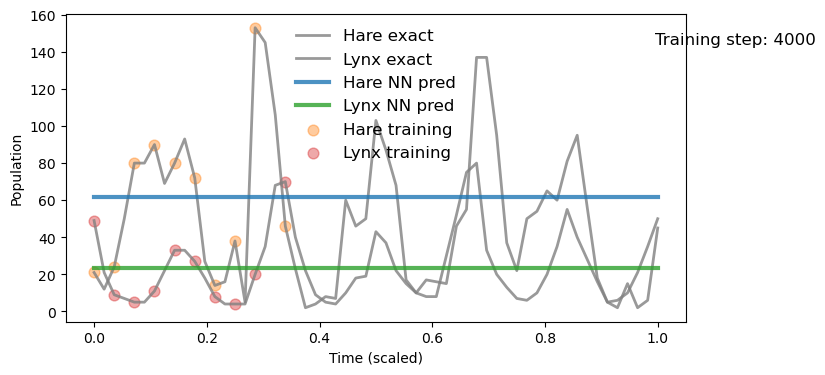

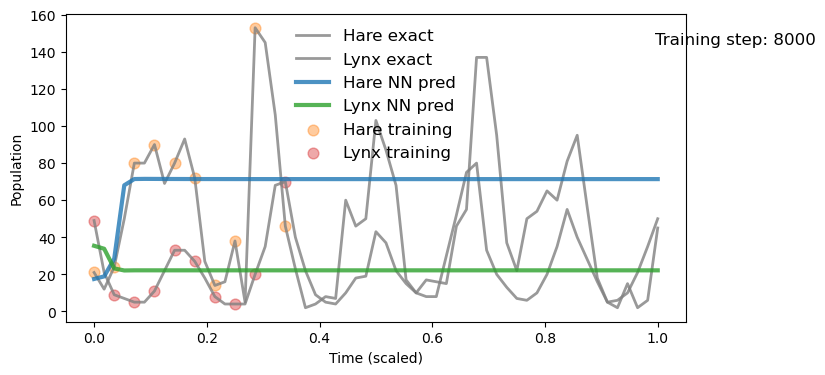

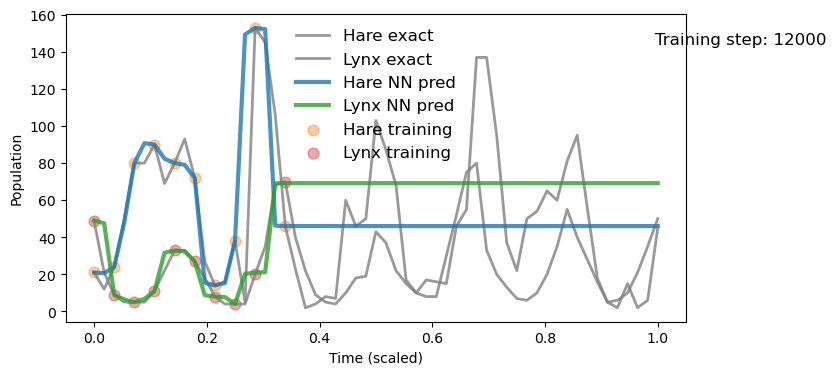

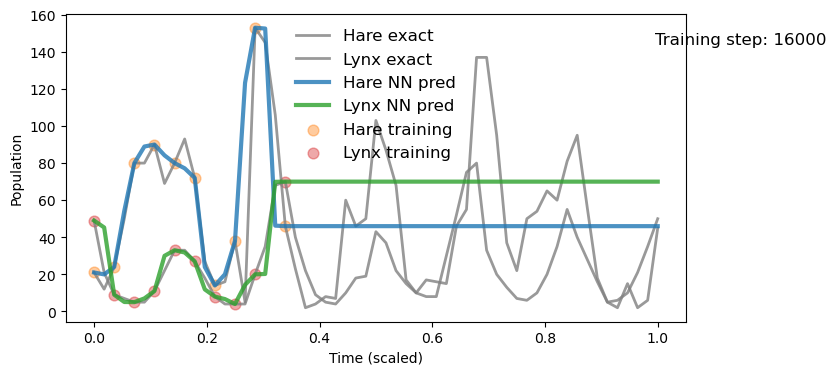

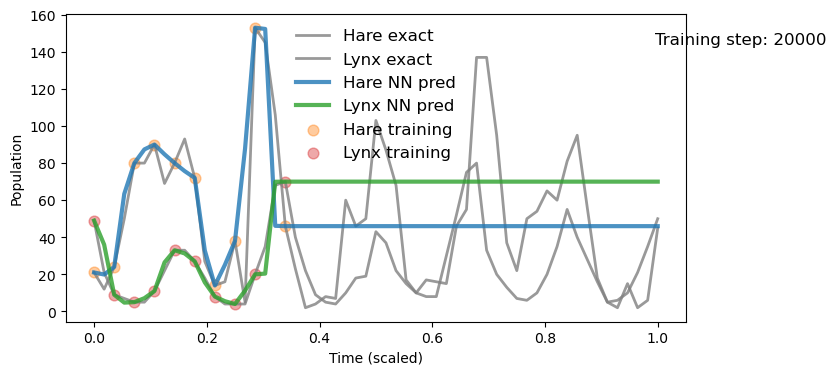

In [65]:
## 1968

file = pd.read_csv("Leigh1968_harelynx.csv")

time = file["year"].to_numpy()
hare = file["hare"].to_numpy()
lynx = file["lynx"].to_numpy()

sort_idx = np.argsort(time)
time = time[sort_idx]
time = time - time[0]
time = time / time[-1]
hare = hare[sort_idx]/1000
lynx = lynx[sort_idx]/1000


t_eval = tc.from_numpy(time).float().unsqueeze(1)
x = tc.from_numpy(hare).unsqueeze(1).float()
y = tc.from_numpy(lynx).unsqueeze(1).float()

###########################################################
sel_end = (x.shape[0])//3 
obs = sel_end//2 + 1 
sel = np.linspace(0, sel_end, obs)
sel = np.int32(sel)

t_data = t_eval[sel]
x_data =  x[sel]
y_data =  y[sel]
all_data = np.hstack([x, y]) 
sel_data = np.hstack([x_data, y_data]) 

all_data = tc.from_numpy(all_data).float()  
sel_data = tc.from_numpy(sel_data).float()  

# train standard neural network to fit training data
tc.manual_seed(123)
model = FCN(1, 2, 64, 4) # one input two outputs, 64 neurons, 4 layers
optimizer = tc.optim.Adam(model.parameters(),lr=1e-3)

for i in range(20000):
    optimizer.zero_grad()
    pred = model(t_data)
    loss = tc.mean((pred - sel_data)**2)
    loss.backward()
    optimizer.step()    
    
    # plot the result as training progresses
    if (i+1) % 4000 == 0: 
        pred = model(t_eval).detach()
        plot_result(t_eval, all_data, t_data, sel_data, pred, step=i+1)        
        plt.show()